## 0. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import xgboost as xgb

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import r2_score

## 1. Read Dataset as DataFrame --> "business.csv"

In [2]:
cwd = os.getcwd()

folder_name = "data"

# Dataset contains flight information and prices
file_name = "business+economy.csv"

file_p = os.path.join(cwd, folder_name, file_name)

data = pd.read_csv(file_p)

## 2. Dataset Info & Summary

In [3]:
data.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


#### Dataset Information

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [5]:
data.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


#### Dataset Features Explanation

In [6]:
"""
Source From: https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction 
"""

'\nSource From: https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction \n'

In [7]:
"""
1) Airline: 

    The name of the airline company is stored in the airline column. 
    It is a categorical feature having 6 different airlines.

2) Flight: 
    
    Flight stores information regarding the plane's flight code. 
    It is a categorical feature.

3) Source City: 
    
    City from which the flight takes off. 
    It is a categorical feature having 6 unique cities.

4) Departure Time: 

    This is a derived categorical feature obtained created by grouping time periods into bins. 
    It stores information about the departure time and have 6 unique time labels.

5) Stops: 

    A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.

6) Arrival Time: 

    This is a derived categorical feature created by grouping time intervals into bins. 
    It has six distinct time labels and keeps information about the arrival time.

7) Destination City: 
    
    City where the flight will land. 
    It is a categorical feature having 6 unique cities.

8) Class: 
    
    A categorical feature that contains information on seat class.
    It has two distinct values: Business and Economy.

9) Duration: 
    
    A continuous feature that displays the overall amount of time it takes to travel between cities in hours.

10) Days Left: 
    
    This is a derived characteristic that is calculated by subtracting the trip date by the booking date.

11) Price: 

    Target variable stores information of the ticket price.
"""

"\n1) Airline: \n\n    The name of the airline company is stored in the airline column. \n    It is a categorical feature having 6 different airlines.\n\n2) Flight: \n\n    Flight stores information regarding the plane's flight code. \n    It is a categorical feature.\n\n3) Source City: \n\n    City from which the flight takes off. \n    It is a categorical feature having 6 unique cities.\n\n4) Departure Time: \n\n    This is a derived categorical feature obtained created by grouping time periods into bins. \n    It stores information about the departure time and have 6 unique time labels.\n\n5) Stops: \n\n    A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.\n\n6) Arrival Time: \n\n    This is a derived categorical feature created by grouping time intervals into bins. \n    It has six distinct time labels and keeps information about the arrival time.\n\n7) Destination City: \n\n    City where the flight will land. \

#### Drop Unrequired Feature Columns

In [8]:
# First column --> Column counting for ticket number
data = data.iloc[:, 1:]

# Column of flight's code --> Not important
data = data.drop('flight', axis=1)

In [9]:
data.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


#### Dataset Features Types

In [10]:
categorical_features_label = data.select_dtypes(include=['object']).columns.to_list()

print(categorical_features_label)

['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']


In [11]:
all_features_label = data.columns.to_list()

print("\n================ Unique Values of Each Feature in Dataset =================\n")

for i in range(0, data.shape[1]):

    feature_label = all_features_label[i]

    if feature_label in categorical_features_label:
        unique_values = data[feature_label].unique()

        print(f"{feature_label}: {unique_values}")
    
    else:
        min_val = data[feature_label].min()
        max_val = data[feature_label].max()

        print(f"{feature_label}: {min_val} ~ {max_val}")


================ Unique Values of Each Feature in Dataset =================

airline: ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
source_city: ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
departure_time: ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
stops: ['zero' 'one' 'two_or_more']
arrival_time: ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
destination_city: ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
class: ['Economy' 'Business']
duration: 0.83 ~ 49.83
days_left: 1 ~ 49
price: 1105 ~ 123071


## 3. Missing Value Check

In [12]:
data.isnull().sum()

airline             0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

## 5. Feature Distribution Graphs

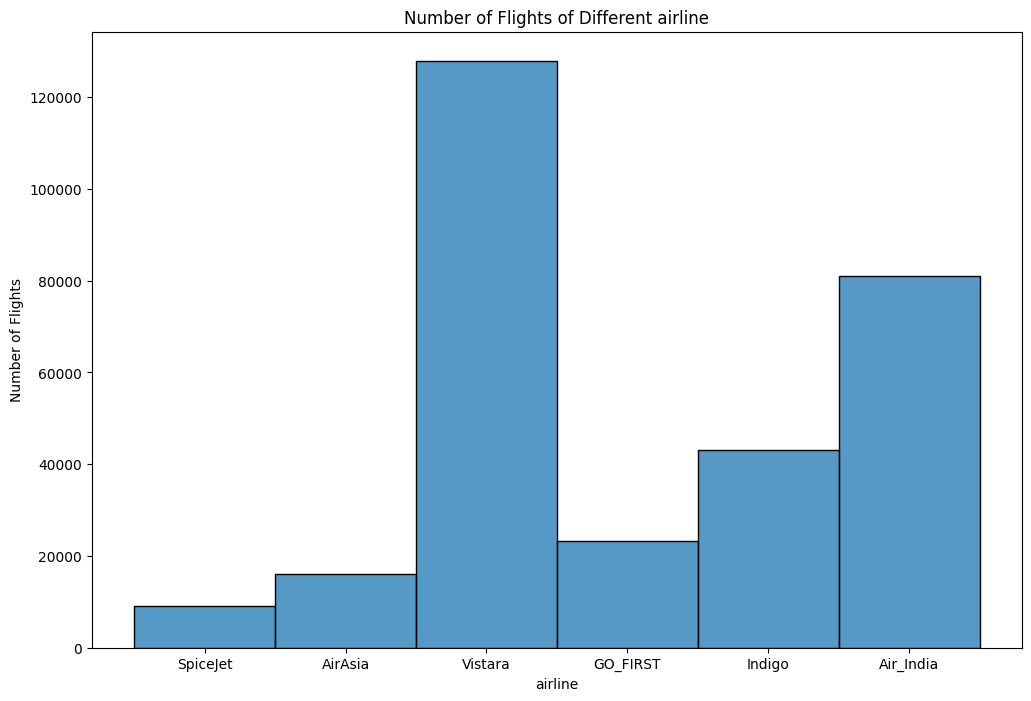

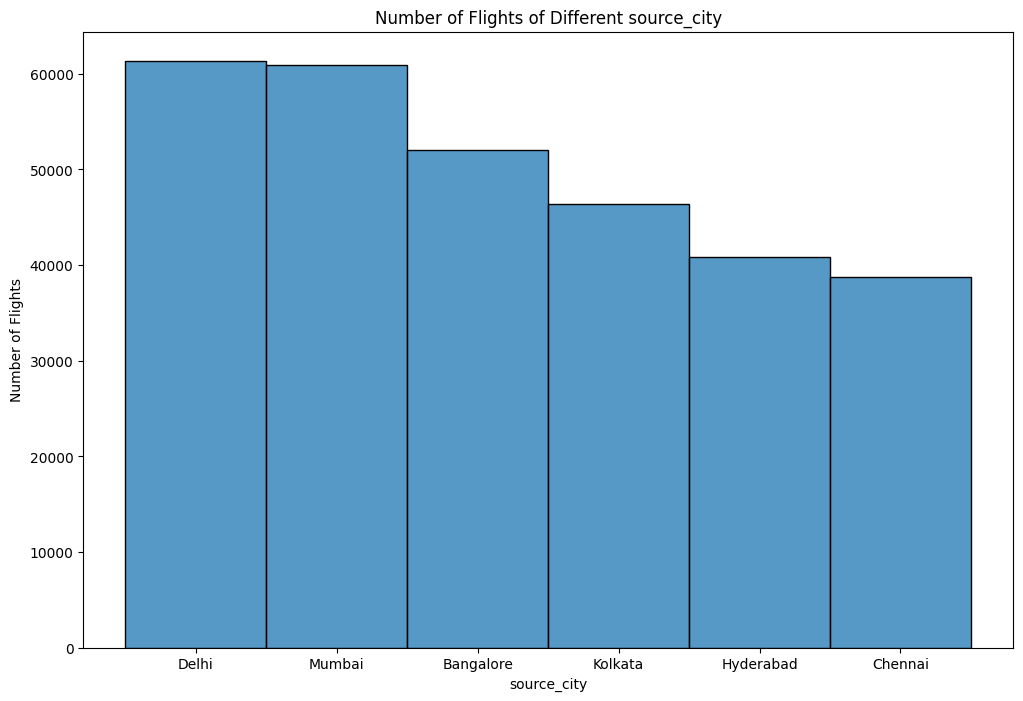

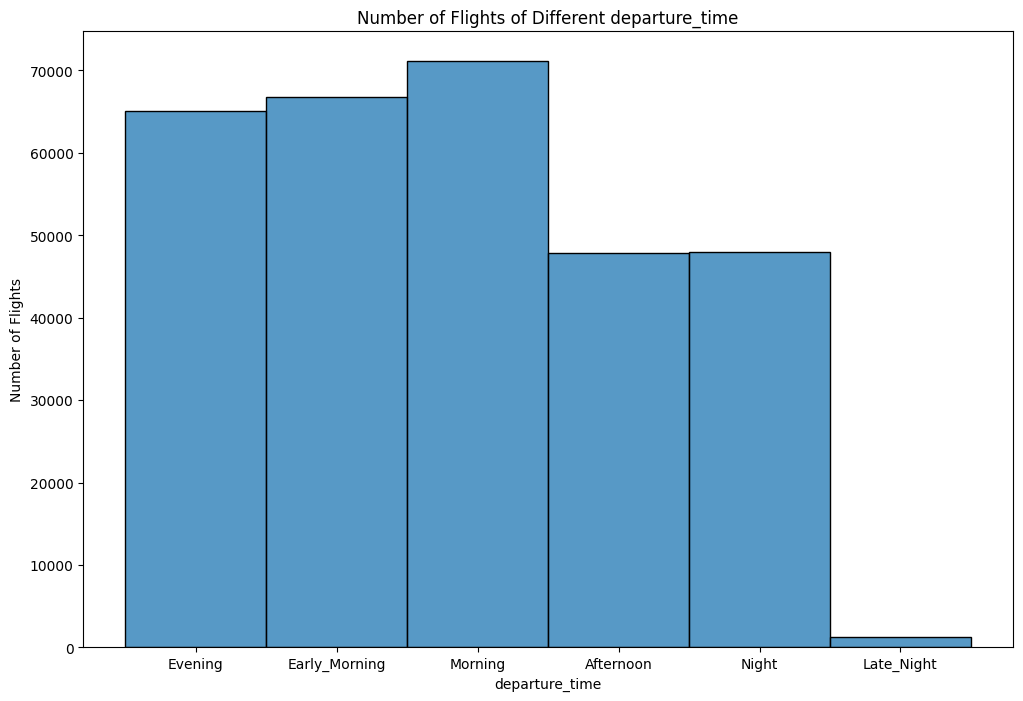

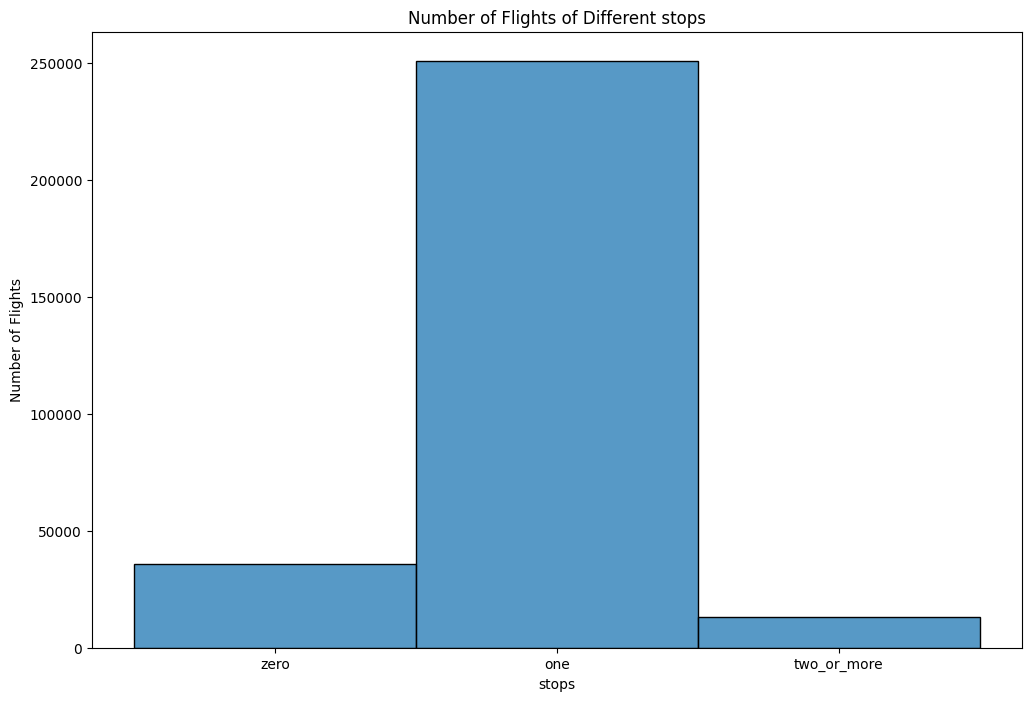

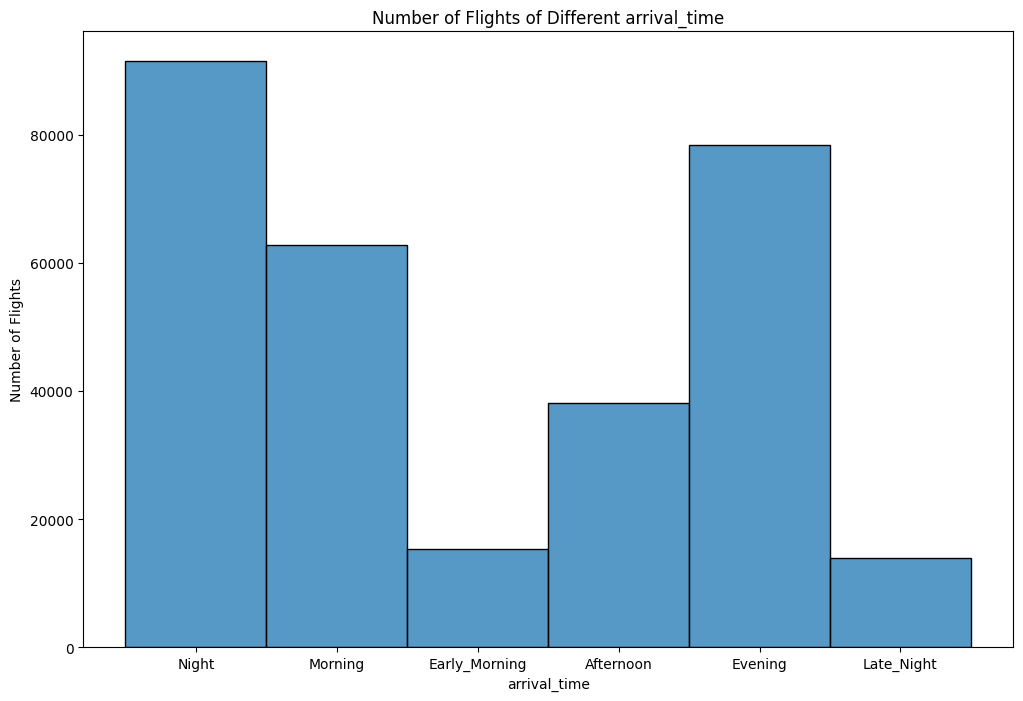

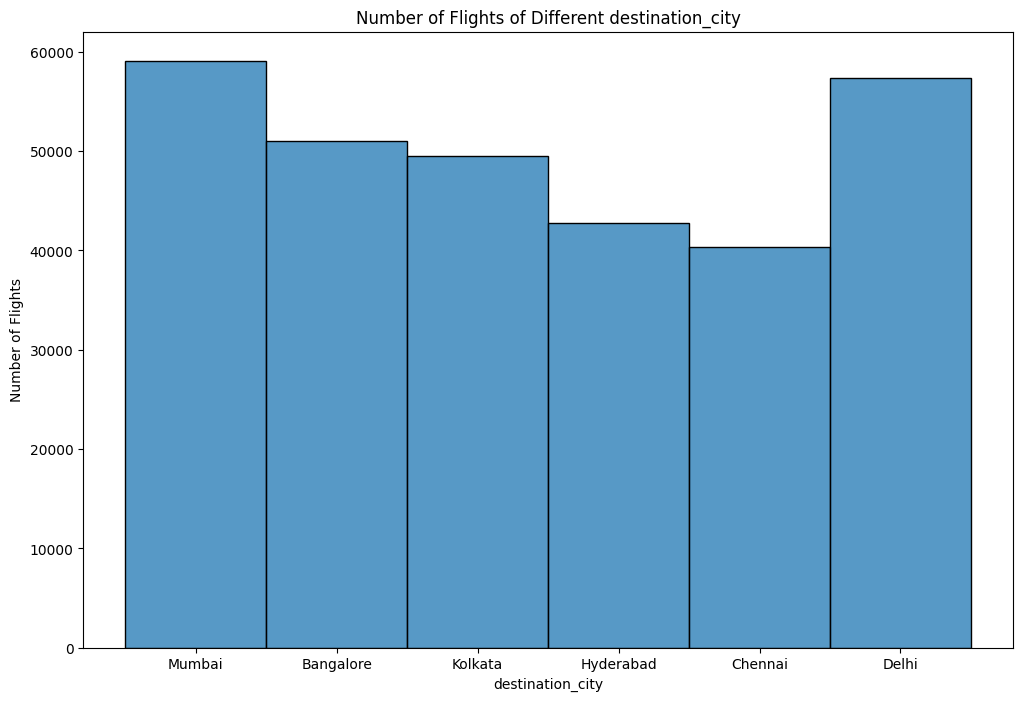

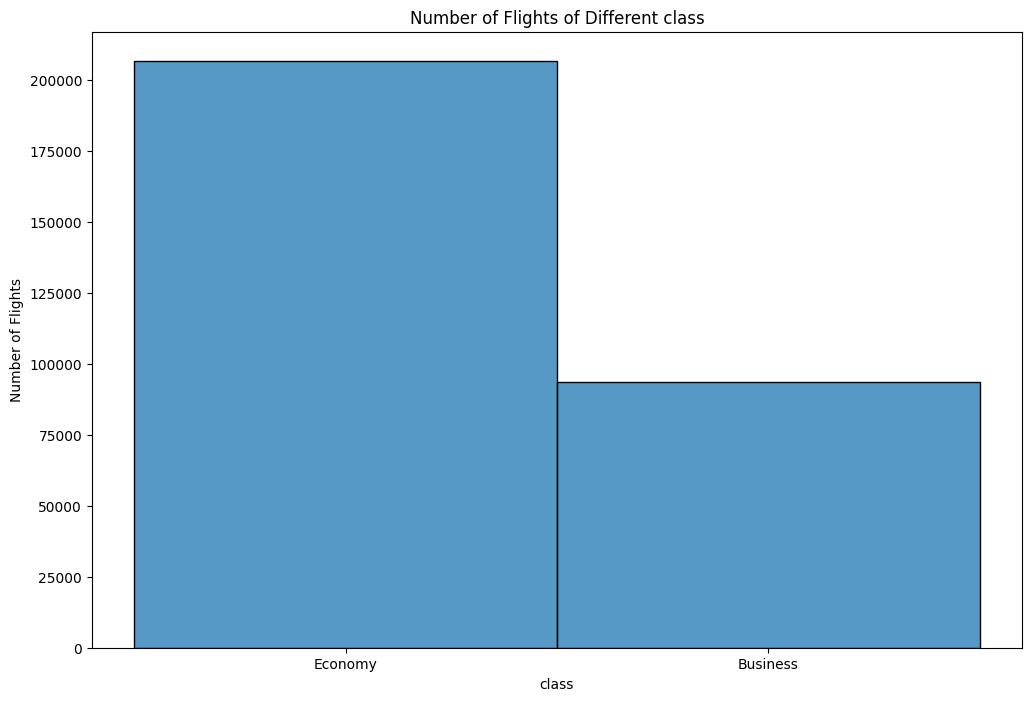

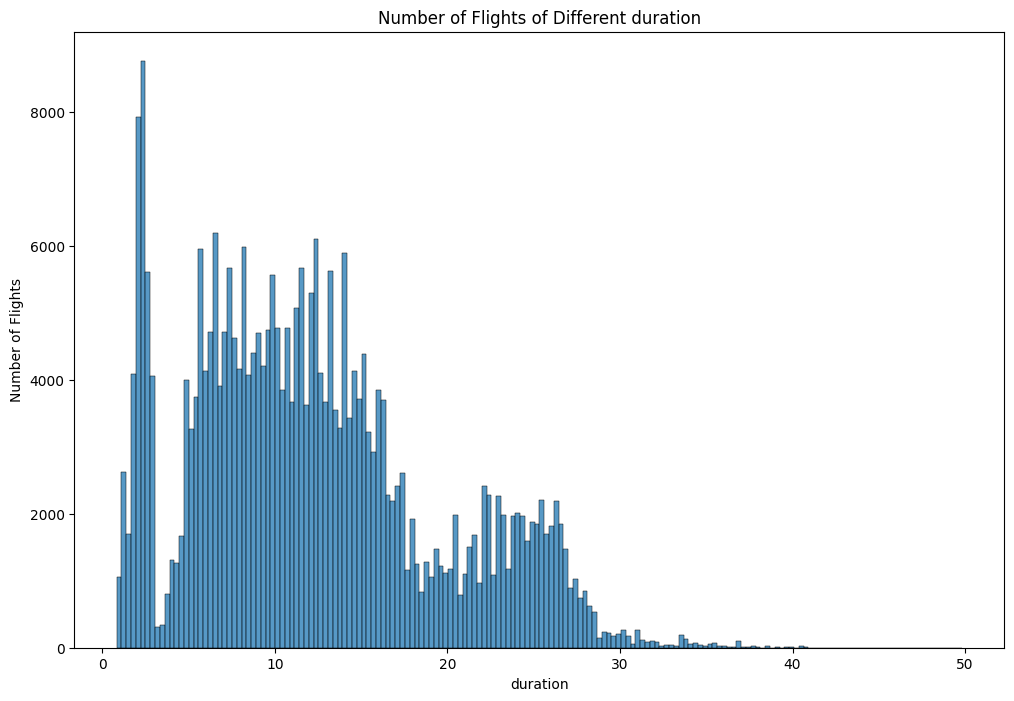

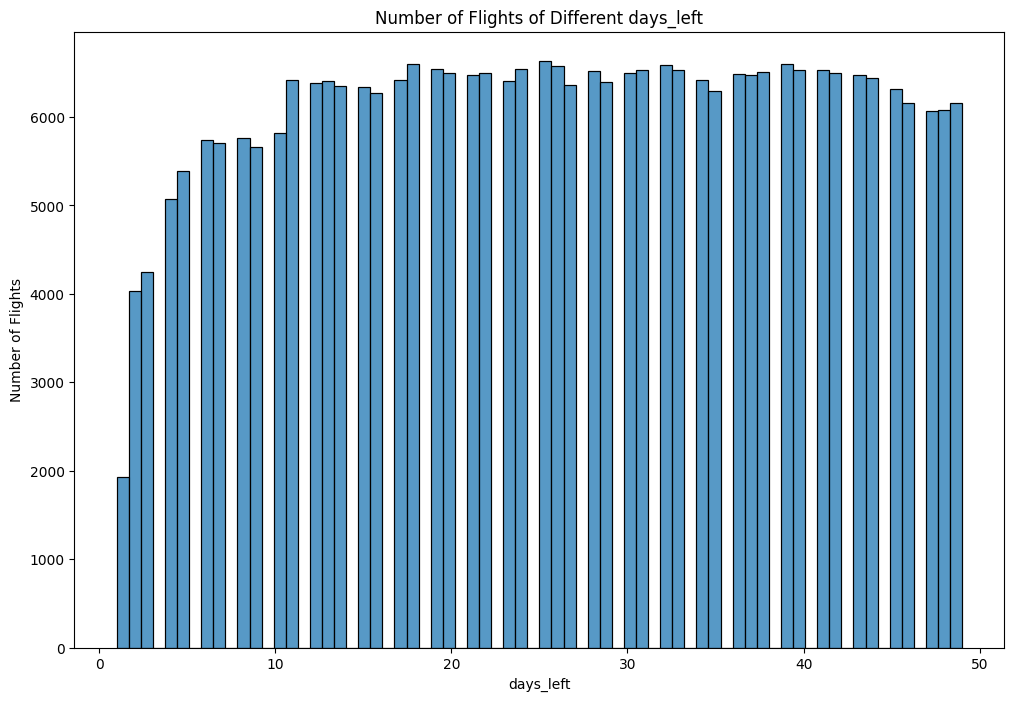

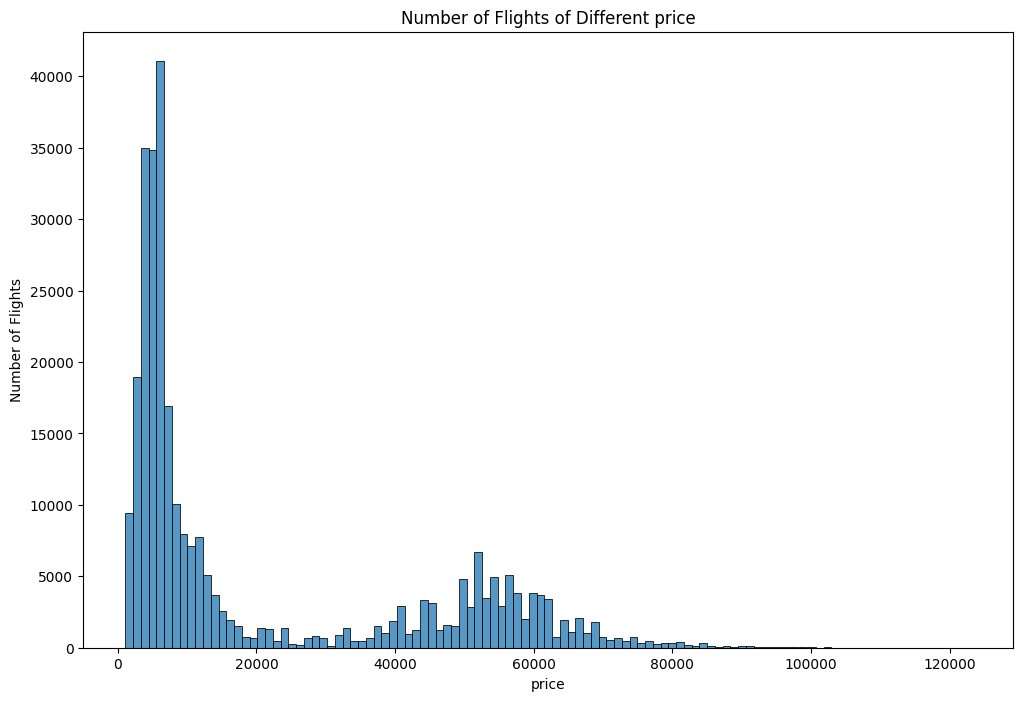

In [13]:
column_labels = data.columns.tolist()

for column_name in column_labels:
    fig = plt.figure(figsize=(12,8))
    
    sns.histplot(data=data, x=column_name)

    graph_title = "Number of Flights of Different " + column_name

    plt.ylabel("Number of Flights")
    plt.xlabel(column_name)
    plt.title(graph_title)
    plt.show()

## 6. Dataset Feature Type Casting

#### Extract Features and Target Variable

In [14]:
y = data['price']

X = data.drop('price', axis=1)

In [15]:
for feature_label in categorical_features_label:
    X[feature_label] = X[feature_label].astype('category')

In [16]:
print(X.dtypes)

airline             category
source_city         category
departure_time      category
stops               category
arrival_time        category
destination_city    category
class               category
duration             float64
days_left              int64
dtype: object


In [17]:
X.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1


## 7. Train Test Split of Datasets

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3, 
                                                    random_state=42,
                                                    shuffle=True)

In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 210107 entries, 2406 to 121958
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   airline           210107 non-null  category
 1   source_city       210107 non-null  category
 2   departure_time    210107 non-null  category
 3   stops             210107 non-null  category
 4   arrival_time      210107 non-null  category
 5   destination_city  210107 non-null  category
 6   class             210107 non-null  category
 7   duration          210107 non-null  float64 
 8   days_left         210107 non-null  int64   
dtypes: category(7), float64(1), int64(1)
memory usage: 6.2 MB


In [20]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90046 entries, 27131 to 108970
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   airline           90046 non-null  category
 1   source_city       90046 non-null  category
 2   departure_time    90046 non-null  category
 3   stops             90046 non-null  category
 4   arrival_time      90046 non-null  category
 5   destination_city  90046 non-null  category
 6   class             90046 non-null  category
 7   duration          90046 non-null  float64 
 8   days_left         90046 non-null  int64   
dtypes: category(7), float64(1), int64(1)
memory usage: 2.7 MB


In [21]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 210107 entries, 2406 to 121958
Series name: price
Non-Null Count   Dtype
--------------   -----
210107 non-null  int64
dtypes: int64(1)
memory usage: 3.2 MB


In [22]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 90046 entries, 27131 to 108970
Series name: price
Non-Null Count  Dtype
--------------  -----
90046 non-null  int64
dtypes: int64(1)
memory usage: 1.4 MB


## 8. Setting Up Model

In [23]:
model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, 
                         max_depth=12,
                         learning_rate=0.2,
                         colsample_bytree = 0.8,
                         min_child_weight=15,
                         subsample=0.8,
                         random_state=42,
                         tree_method='hist',
                         enable_categorical=True)



#### Model Fitting

In [24]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=12,
             max_leaves=None, min_child_weight=15, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

## 9. Model Evaluation

In [25]:
y_pred = model.predict(X_test)

rmse_value = rmse(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse_value:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 2551.361
R²: 0.987


#### Residuals Analysis

In [26]:
residuals = np.squeeze(np.array(y_test) - np.array(y_pred))

residuals_df = pd.DataFrame(residuals)

In [27]:
residuals_df.head()

,0
0,-104.275879
1,-1603.617188
2,-163.752441
3,-1219.640625
4,163.126465


In [28]:
residuals_df.describe()

,0
count,90046.000000
mean,-6.728035
std,2551.366599
min,-30349.406250
25%,-759.387939
50%,-103.100098
75%,441.656631
max,41908.234375


In [29]:
residuals_df_abs = pd.DataFrame(residuals)

residuals_df_abs.describe()

,0
count,90046.000000
mean,-6.728035
std,2551.366599
min,-30349.406250
25%,-759.387939
50%,-103.100098
75%,441.656631
max,41908.234375


<Axes: title={'center': 'Residual Graph of Testing'}, xlabel='No. of Prediction', ylabel='Residual Magnitude'>

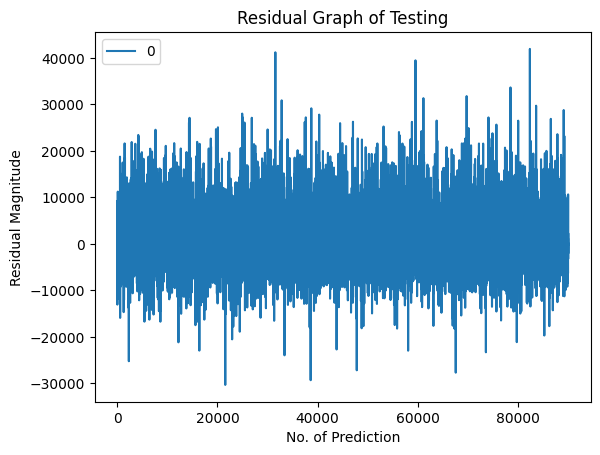

In [30]:
residuals_df.plot(title="Residual Graph of Testing",
                  xlabel="No. of Prediction",
                  ylabel="Residual Magnitude")

<Axes: title={'center': 'Residual Density Graph'}, ylabel='Density'>

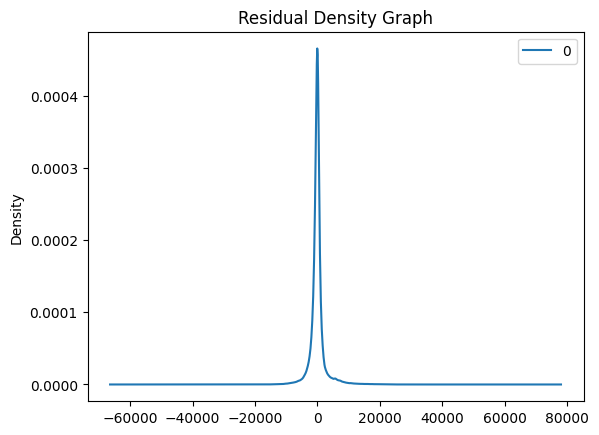

In [31]:
residuals_df.plot(kind='kde', title="Residual Density Graph")

#### Graph of Actual vs Prediction Values

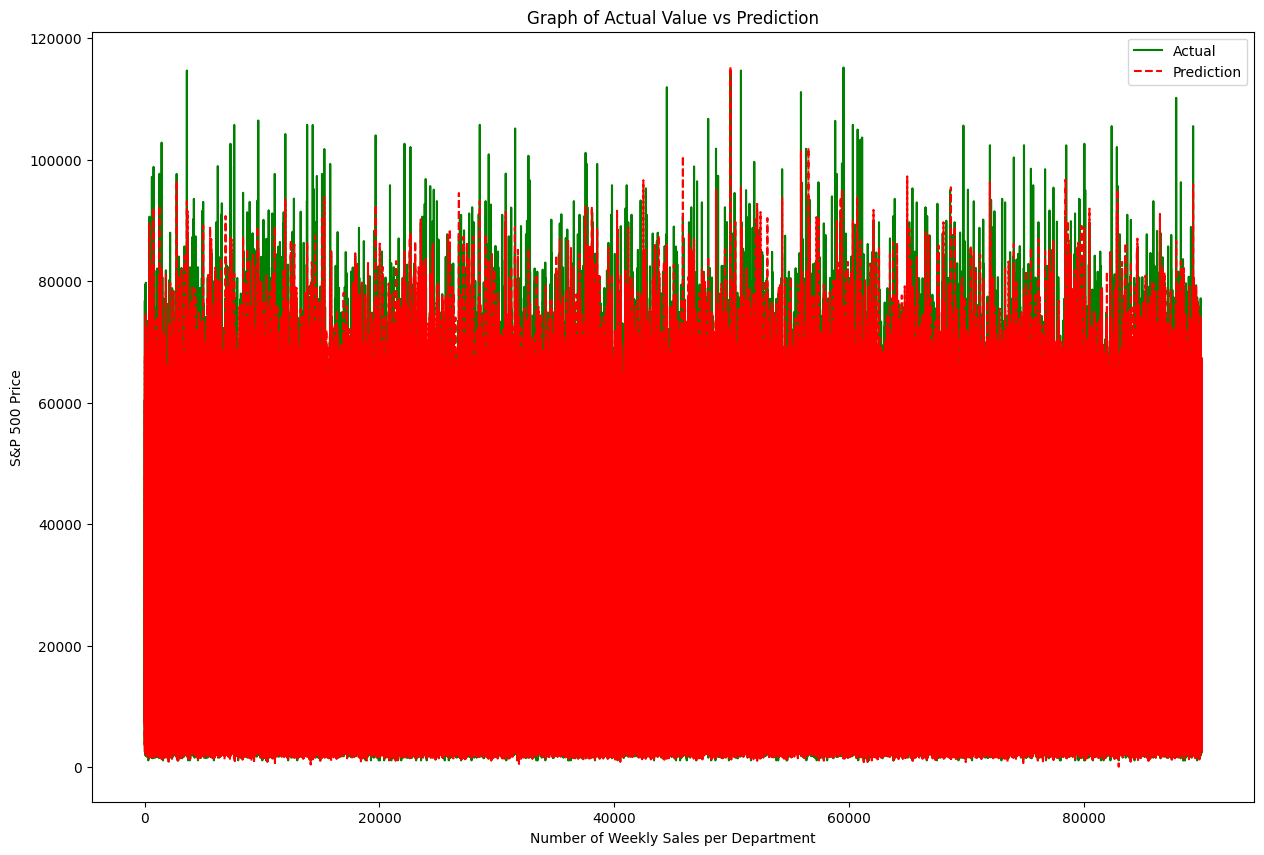

In [32]:
fig = plt.figure(figsize=(15, 10))

plt.plot(y_test.reset_index(drop=True), label="Actual", color='green')
plt.plot(y_pred, label="Prediction", color='red', linestyle='dashed')

plt.title("Graph of Actual Value vs Prediction")
plt.xlabel("Number of Weekly Sales per Department")
plt.ylabel("S&P 500 Price")

plt.legend()
plt.show()

## 10. Hyperparameter Grid Search

In [33]:
param_grid = {
    'max_depth': [3, 6, 9, 12],
    'min_child_weight': [1, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.25],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(estimator=model, 
                           param_grid=param_grid, 
                           cv=5, 
                           n_jobs=-1, 
                           verbose=3)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 12, 'min_child_weight': 5, 'subsample': 1.0}


In [34]:
y_pred = grid_search.predict(X_test)

rmse_value = rmse(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE of Best Params: {rmse_value:.3f}')
print(f'R² of Best Params: {r2:.3f}')

RMSE of Best Params: 2502.508
R² of Best Params: 0.988


## 11. XGBoost Feature Importance

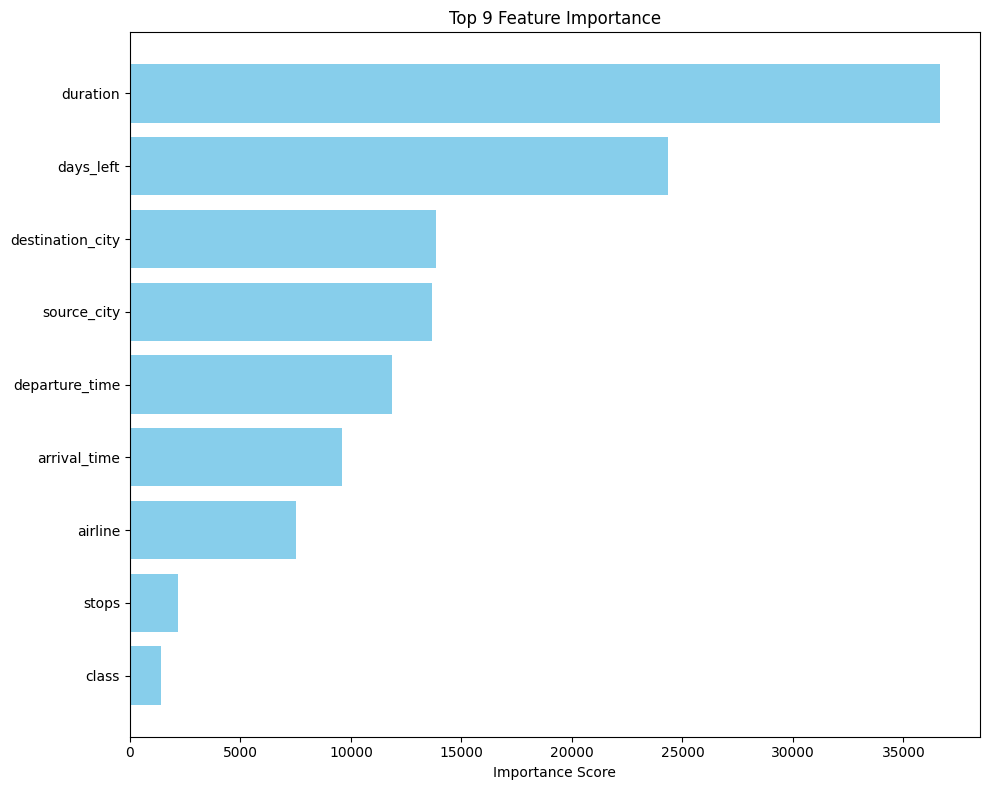

In [35]:
importance = model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 9
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()